In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

ASSIGNMENT 2: Iris Dataset


<Figure size 1000x800 with 0 Axes>

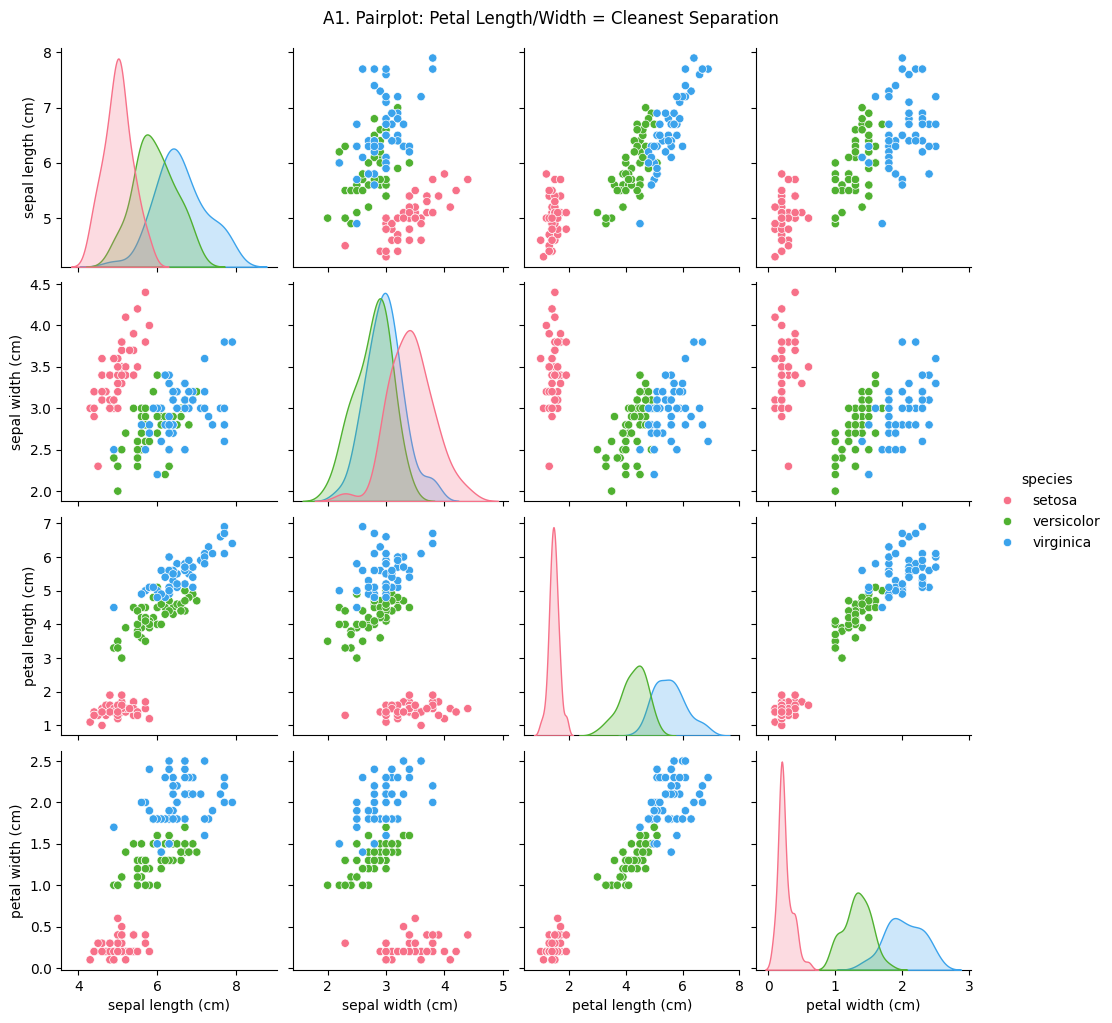

A1. Analysis: Petal length/width best separation, sepal length/width problematic

A2. Feature means by species:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01              3.43               1.46   
versicolor               5.94              2.77               4.26   
virginica                6.59              2.97               5.55   

            petal width (cm)  
species                       
setosa                  0.25  
versicolor              1.33  
virginica               2.03  
Setosa easiest to separate (small petals), versicolor/virginica most similar


In [2]:

print("ASSIGNMENT 2: Iris Dataset")
iris = load_iris()
X_i, y_i = iris.data, iris.target

df_i = pd.DataFrame(X_i, columns=iris.feature_names)
df_i['species'] = pd.Categorical.from_codes(y_i, iris.target_names)
plt.figure(figsize=(10, 8))
sns.pairplot(df_i, hue='species', palette='husl')
plt.suptitle("A1. Pairplot: Petal Length/Width = Cleanest Separation", y=1.02)
plt.show()

print("A1. Analysis: Petal length/width best separation, sepal length/width problematic")

print("\nA2. Feature means by species:")
species_means = df_i.groupby('species', observed=False)[iris.feature_names].mean()

print(species_means.round(2))

print("Setosa easiest to separate (small petals), versicolor/virginica most similar")


In [4]:

X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_i, y_i, test_size=0.2, stratify=y_i, random_state=42)
scaler_i = StandardScaler()
X_i_train_scaled = scaler_i.fit_transform(X_i_train)
X_i_test_scaled = scaler_i.transform(X_i_test)

print("A3. Data standardized + stratified split (maintains balance)")

A3. Data standardized + stratified split (maintains balance)


In [5]:
print("\nB1. Multi-class Strategies (Linear Kernel):")
for strategy in ['ovo', 'ovr']:
    svm = SVC(kernel='linear', decision_function_shape=strategy, random_state=42)
    svm.fit(X_i_train_scaled, y_i_train)
    acc = svm.score(X_i_test_scaled, y_i_test)
    print(f"{strategy.upper()}: Test Accuracy = {acc:.3f}")


B1. Multi-class Strategies (Linear Kernel):
OVO: Test Accuracy = 1.000
OVR: Test Accuracy = 1.000


In [6]:
print("\nC1. Decision Boundary Visualization (Petal Length vs Width)")

petal_idx = [2, 3]
X_petal_train = X_i_train_scaled[:, petal_idx]
X_petal_test = X_i_test_scaled[:, petal_idx]



C1. Decision Boundary Visualization (Petal Length vs Width)



1. LINEAR KERNEL:


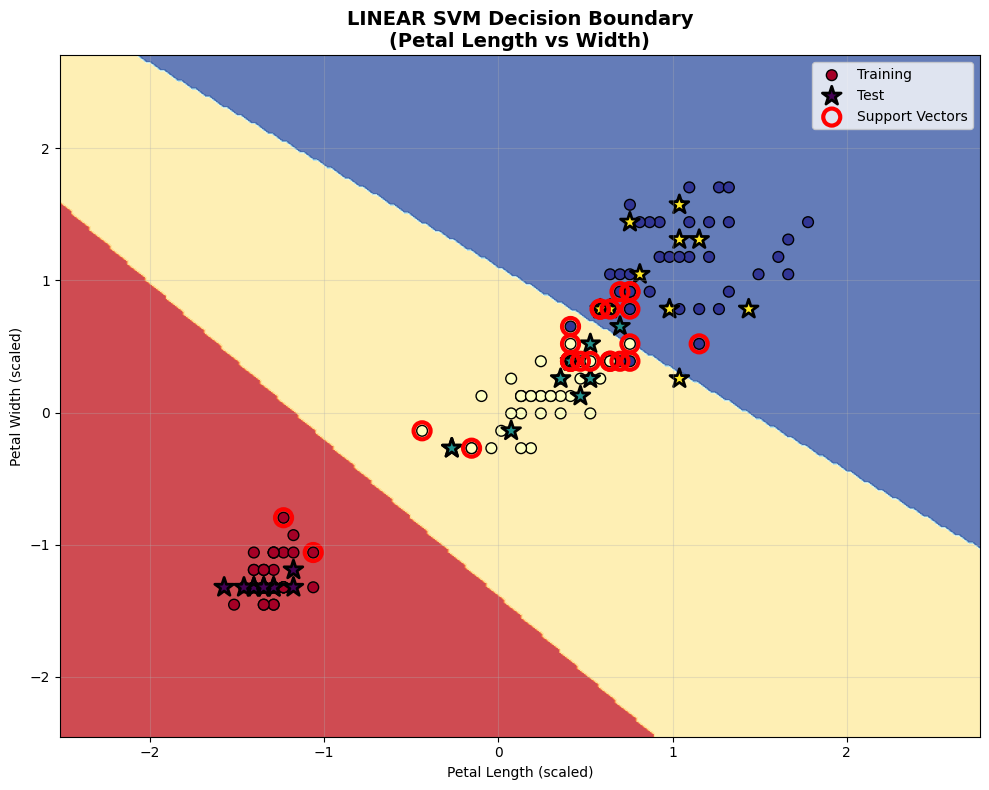


2. POLYNOMIAL KERNEL (degree=3):


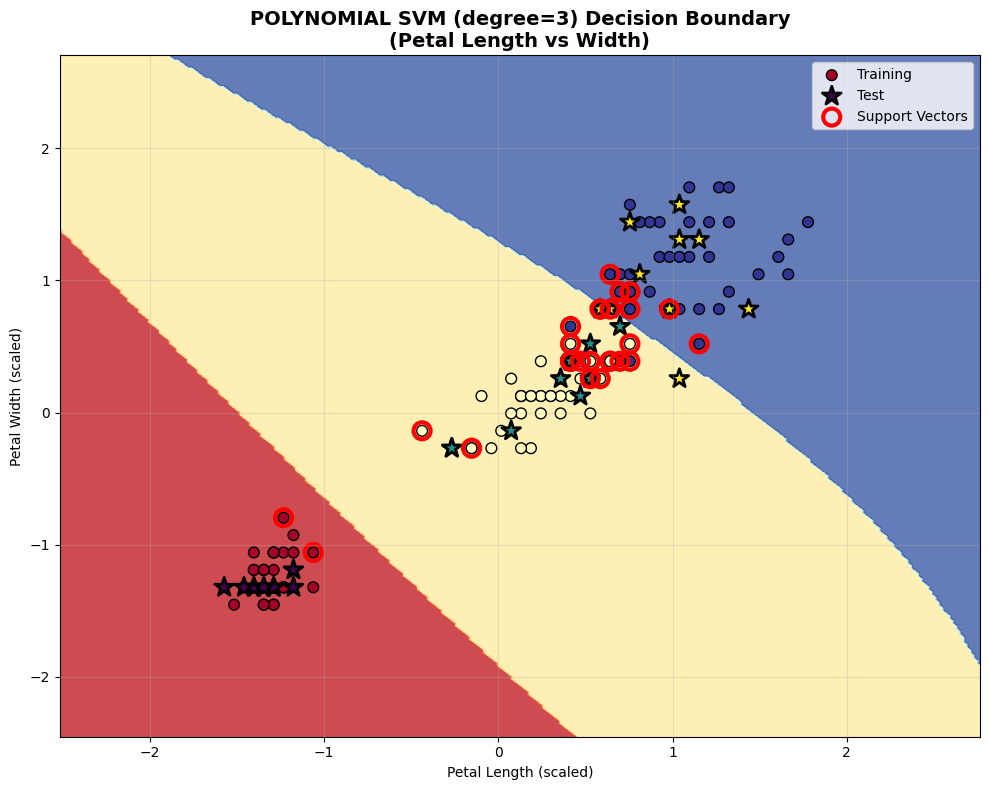


3. RBF KERNEL:


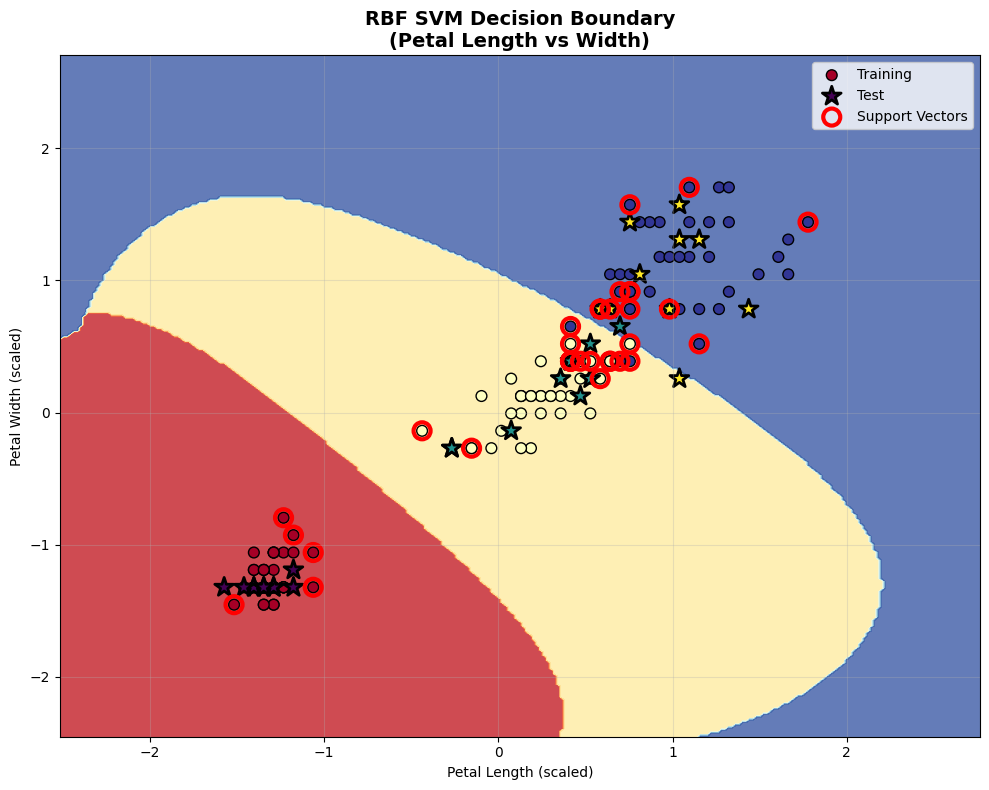

In [7]:
print("\n1. LINEAR KERNEL:")
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_petal_train, y_i_train)

h = 0.02
x_min, x_max = X_petal_train[:, 0].min() - 1, X_petal_train[:, 0].max() + 1
y_min, y_max = X_petal_train[:, 1].min() - 1, X_petal_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z_linear = svm_linear.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))  
plt.contourf(xx, yy, Z_linear, alpha=0.8, cmap=plt.cm.RdYlBu)
plt.scatter(X_petal_train[:, 0], X_petal_train[:, 1], c=y_i_train, 
           cmap=plt.cm.RdYlBu, edgecolors='k', s=60, label='Training')
plt.scatter(X_petal_test[:, 0], X_petal_test[:, 1], c=y_i_test, 
           marker='*', s=200, edgecolors='black', linewidth=2, label='Test')
plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1], 
           facecolors='none', edgecolors='red', s=150, linewidth=3, label='Support Vectors')
plt.title('LINEAR SVM Decision Boundary\n(Petal Length vs Width)', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

print("\n2. POLYNOMIAL KERNEL (degree=3):")
svm_poly = SVC(kernel='poly', degree=3, gamma='scale', random_state=42)
svm_poly.fit(X_petal_train, y_i_train)
Z_poly = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))  
plt.contourf(xx, yy, Z_poly, alpha=0.8, cmap=plt.cm.RdYlBu)
plt.scatter(X_petal_train[:, 0], X_petal_train[:, 1], c=y_i_train, 
           cmap=plt.cm.RdYlBu, edgecolors='k', s=60, label='Training')
plt.scatter(X_petal_test[:, 0], X_petal_test[:, 1], c=y_i_test, 
           marker='*', s=200, edgecolors='black', linewidth=2, label='Test')
plt.scatter(svm_poly.support_vectors_[:, 0], svm_poly.support_vectors_[:, 1], 
           facecolors='none', edgecolors='red', s=150, linewidth=3, label='Support Vectors')
plt.title('POLYNOMIAL SVM (degree=3) Decision Boundary\n(Petal Length vs Width)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n3. RBF KERNEL:")
svm_rbf = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_rbf.fit(X_petal_train, y_i_train)
Z_rbf = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 8))  
plt.contourf(xx, yy, Z_rbf, alpha=0.8, cmap=plt.cm.RdYlBu)
plt.scatter(X_petal_train[:, 0], X_petal_train[:, 1], c=y_i_train, 
           cmap=plt.cm.RdYlBu, edgecolors='k', s=60, label='Training')
plt.scatter(X_petal_test[:, 0], X_petal_test[:, 1], c=y_i_test, 
           marker='*', s=200, edgecolors='black', linewidth=2, label='Test')
plt.scatter(svm_rbf.support_vectors_[:, 0], svm_rbf.support_vectors_[:, 1], 
           facecolors='none', edgecolors='red', s=150, linewidth=3, label='Support Vectors')
plt.title('RBF SVM Decision Boundary\n(Petal Length vs Width)', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
print("\nD1. 10-fold Cross-Validation:")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
kernels = {
    'Linear': SVC(kernel='linear'),
    'Polynomial': SVC(kernel='poly', degree=3),
    'RBF': SVC(kernel='rbf', gamma='scale')
}

for name, svm_cv in kernels.items():
    X_i_scaled = scaler_i.fit_transform(X_i)
    scores = cross_val_score(svm_cv, X_i_scaled, y_i, cv=cv)
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")


D1. 10-fold Cross-Validation:
Linear: 0.947 ± 0.058
Polynomial: 0.920 ± 0.083
RBF: 0.960 ± 0.044
